## Gyroid

$$ \sin(x)\cos(y)+\sin(y)\cos(z)+\sin(z)\cos(x)=0$$

/var/folders/_b/cfj7mly10r9f3nkywrlqnl300000gn/T/ipykernel_67742/3356576128.py:84: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


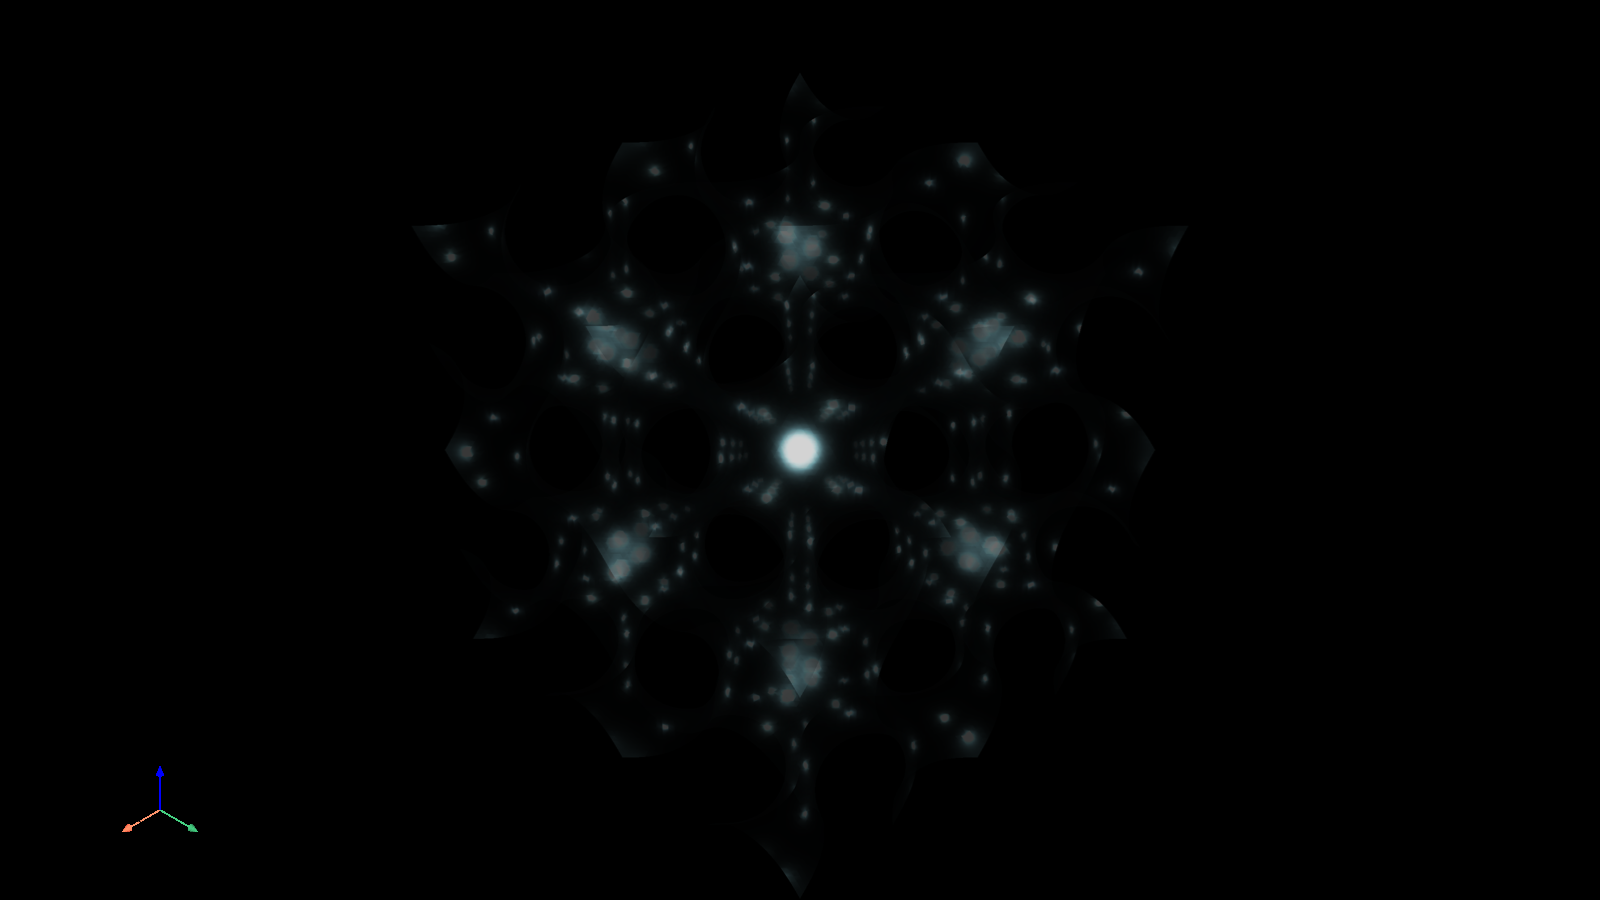

In [4]:
import numpy as np
import pyvista as pv

# ---------------------------------------------------------
# GRID
# ---------------------------------------------------------

N = 120

x = np.linspace(-np.pi * 2, np.pi * 2, N)
y = np.linspace(-np.pi * 2, np.pi * 2, N)
z = np.linspace(-np.pi * 2, np.pi * 2, N)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

# ---------------------------------------------------------
# GYROID FIELD
# ---------------------------------------------------------

F = (
    np.sin(X) * np.cos(Y)
    + np.sin(Y) * np.cos(Z)
    + np.sin(Z) * np.cos(X)
)

# ---------------------------------------------------------
# VOLUME
# ---------------------------------------------------------

grid = pv.ImageData()

grid.dimensions = np.array(F.shape) + 1
grid.origin = (x.min(), y.min(), z.min())

grid.spacing = (
    (x.max() - x.min()) / N,
    (y.max() - y.min()) / N,
    (z.max() - z.min()) / N,
)

grid.cell_data["values"] = F.flatten(order="F")

# ---------------------------------------------------------
# STRUCTURED GRID
# ---------------------------------------------------------

grid = pv.StructuredGrid(X, Y, Z)

grid["values"] = F.ravel(order="F")

# ---------------------------------------------------------
# ISOSURFACE
# ---------------------------------------------------------

surface = grid.contour(
    isosurfaces=[0.0],
    scalars="values",
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plotter = pv.Plotter(off_screen=True, window_size=(VIEW_SIZE, VIEW_SIZE))

plotter.set_background("black")

plotter.enable_anti_aliasing()

plotter.add_mesh(
    surface,
    smooth_shading=True,
    color="#66e0ff",
    opacity=0.22,
    metallic=True,
    pbr=True,
    roughness=0.15,
)

plotter.add_axes()

plotter.camera_position = "iso"

plotter.show()

In [5]:
from pathlib import Path
import shutil
import subprocess
import numpy as np
import pyvista as pv


OUTPUT_FORMAT = "webm"  # "webm" | "gif" | "mp4"
FPS = 24
TOTAL_FRAMES = 180

ANIMATIONS_DIR = Path("media-site/animations")
ANIMATION_NAME = "math_gyroid_rotation"

N = 120
WINDOW_SIZE = (1200, 720)


def normalize_output_format(fmt: str) -> str:
    fmt = fmt.lower().strip()
    if fmt not in {"webm", "gif", "mp4"}:
        raise ValueError("OUTPUT_FORMAT must be webm, gif or mp4")
    return fmt


def build_gyroid_surface():
    x = np.linspace(-2 * np.pi, 2 * np.pi, N)
    y = np.linspace(-2 * np.pi, 2 * np.pi, N)
    z = np.linspace(-2 * np.pi, 2 * np.pi, N)

    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    F = (
        np.sin(X) * np.cos(Y)
        + np.sin(Y) * np.cos(Z)
        + np.sin(Z) * np.cos(X)
    )

    grid = pv.StructuredGrid(X, Y, Z)
    grid["values"] = F.ravel(order="F")

    surface = grid.contour(
        isosurfaces=[0.0],
        scalars="values",
    )

    return surface


def render_frames(surface):
    frame_dir = ANIMATIONS_DIR / ANIMATION_NAME / "_frames"
    frame_dir.mkdir(parents=True, exist_ok=True)

    plotter = pv.Plotter(
        off_screen=True,
        window_size=WINDOW_SIZE,
    )

    plotter.set_background("black")
    plotter.enable_anti_aliasing()

    plotter.add_mesh(
        surface,
        smooth_shading=True,
        color="#66e0ff",
        opacity=0.72,
        specular=1.0,
        specular_power=30,
    )

    plotter.add_mesh(
        surface.extract_feature_edges(
            boundary_edges=True,
            feature_edges=False,
            manifold_edges=False,
        ),
        color="#b8ffff",
        line_width=1,
        opacity=0.22,
    )

    plotter.camera_position = "iso"
    plotter.camera.zoom(1.25)

    for i in range(TOTAL_FRAMES):
        if i % 24 == 0:
            print(f"[RENDER] frame {i}/{TOTAL_FRAMES}")

        angle = 360 * i / TOTAL_FRAMES
        plotter.camera.azimuth = angle
        plotter.camera.elevation = 18 * np.sin(2 * np.pi * i / TOTAL_FRAMES)

        plotter.render()
        plotter.screenshot(str(frame_dir / f"frame_{i:04d}.png"))

    plotter.close()
    return frame_dir


def export_with_ffmpeg(frame_dir: Path, out_path: Path, output_format: str):
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("ffmpeg not found. Install: brew install ffmpeg")

    output_format = normalize_output_format(output_format)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if output_format == "webm":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libvpx-vp9",
            "-b:v", "0",
            "-crf", "34",
            "-pix_fmt", "yuva420p",
            "-auto-alt-ref", "0",
            "-row-mt", "1",
            str(out_path),
        ]

    elif output_format == "mp4":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libx264",
            "-crf", "22",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",
            str(out_path),
        ]

    else:
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-vf", "palettegen",
            str(frame_dir / "palette.png"),
        ]
        subprocess.run(cmd, check=True)

        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-i", str(frame_dir / "palette.png"),
            "-lavfi", "paletteuse",
            "-loop", "0",
            str(out_path),
        ]

    subprocess.run(cmd, check=True)


def main():
    output_format = normalize_output_format(OUTPUT_FORMAT)

    print("[START] Gyroid rotation")
    print(f"[CONFIG] OUTPUT_FORMAT = {output_format}")
    print(f"[CONFIG] FPS = {FPS}")
    print(f"[CONFIG] TOTAL_FRAMES = {TOTAL_FRAMES}")
    print(f"[CONFIG] N = {N}")

    surface = build_gyroid_surface()
    frame_dir = render_frames(surface)

    out_dir = ANIMATIONS_DIR / ANIMATION_NAME
    out_path = out_dir / f"{ANIMATION_NAME}.{output_format}"

    export_with_ffmpeg(frame_dir, out_path, output_format)

    shutil.rmtree(frame_dir, ignore_errors=True)

    print()
    print(f"[CREATED] {ANIMATION_NAME}")
    print(f"          {out_path.resolve()}")
    print()
    print(f"Created 1 animation as '{output_format}' in '{out_dir.resolve()}'")


main()

[START] Gyroid rotation
[CONFIG] OUTPUT_FORMAT = webm
[CONFIG] FPS = 24
[CONFIG] TOTAL_FRAMES = 180
[CONFIG] N = 120
[RENDER] frame 0/180
[RENDER] frame 24/180
[RENDER] frame 48/180
[RENDER] frame 72/180
[RENDER] frame 96/180
[RENDER] frame 120/180
[RENDER] frame 144/180
[RENDER] frame 168/180


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/mloktionov/anaconda3/envs/astro-ai --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1748704173249/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib


[CREATED] math_gyroid_rotation
          /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_gyroid_rotation/math_gyroid_rotation.webm

Created 1 animation as 'webm' in '/Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_gyroid_rotation'


[out#0/webm @ 0x122623a90] video:910KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 1.317453%
frame=  180 fps= 46 q=34.0 Lsize=     922KiB time=00:00:07.50 bitrate=1007.3kbits/s speed= 1.9x    


In [7]:
from pathlib import Path
import shutil
import subprocess
import numpy as np
import pyvista as pv


OUTPUT_FORMAT = "webm"  # "webm" | "gif" | "mp4"
FPS = 24
TOTAL_FRAMES = 180

ANIMATIONS_DIR = Path("media-site/animations")
ANIMATION_NAME = "math_gyroid_scan_slice"

N = 120
WINDOW_SIZE = (1200, 720)


def normalize_output_format(fmt: str) -> str:
    fmt = fmt.lower().strip()
    if fmt not in {"webm", "gif", "mp4"}:
        raise ValueError("OUTPUT_FORMAT must be webm, gif or mp4")
    return fmt


def build_gyroid_surface():
    x = np.linspace(-2 * np.pi, 2 * np.pi, N)
    y = np.linspace(-2 * np.pi, 2 * np.pi, N)
    z = np.linspace(-2 * np.pi, 2 * np.pi, N)

    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

    F = (
        np.sin(X) * np.cos(Y)
        + np.sin(Y) * np.cos(Z)
        + np.sin(Z) * np.cos(X)
    )

    grid = pv.StructuredGrid(X, Y, Z)
    grid["values"] = F.ravel(order="F")

    return grid.contour(isosurfaces=[0.0], scalars="values")


def export_with_ffmpeg(frame_dir: Path, out_path: Path, output_format: str):
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("ffmpeg not found. Install: brew install ffmpeg")

    output_format = normalize_output_format(output_format)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if output_format == "webm":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libvpx-vp9",
            "-b:v", "0",
            "-crf", "34",
            "-pix_fmt", "yuva420p",
            "-auto-alt-ref", "0",
            "-row-mt", "1",
            str(out_path),
        ]
    elif output_format == "mp4":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libx264",
            "-crf", "22",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",
            str(out_path),
        ]
    else:
        subprocess.run([
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-vf", "palettegen",
            str(frame_dir / "palette.png"),
        ], check=True)

        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-i", str(frame_dir / "palette.png"),
            "-lavfi", "paletteuse",
            "-loop", "0",
            str(out_path),
        ]

    subprocess.run(cmd, check=True)


def main():
    output_format = normalize_output_format(OUTPUT_FORMAT)

    print("[START] Gyroid scan slice")
    print(f"[CONFIG] OUTPUT_FORMAT = {output_format}")
    print(f"[CONFIG] FPS = {FPS}")
    print(f"[CONFIG] TOTAL_FRAMES = {TOTAL_FRAMES}")
    print(f"[CONFIG] N = {N}")

    out_dir = ANIMATIONS_DIR / ANIMATION_NAME
    frame_dir = out_dir / "_frames"
    frame_dir.mkdir(parents=True, exist_ok=True)

    surface = build_gyroid_surface()

    plotter = pv.Plotter(off_screen=True, window_size=WINDOW_SIZE)
    plotter.set_background("black")
    plotter.enable_anti_aliasing()

    mesh_actor = plotter.add_mesh(
        surface,
        smooth_shading=True,
        color="#66e0ff",
        opacity=0.25,
        specular=1.0,
        specular_power=30,
    )

    plotter.camera_position = "iso"
    plotter.camera.zoom(1.3)

    z_min, z_max = surface.bounds[4] * 0.82, surface.bounds[5] * 0.82

    for i in range(TOTAL_FRAMES):
        if i % 24 == 0:
            print(f"[RENDER] frame {i}/{TOTAL_FRAMES}")

        phase = 2 * np.pi * i / TOTAL_FRAMES
        z = z_min + (z_max - z_min) * (0.5 + 0.5 * np.sin(phase))

    sliced = surface.slice(
        normal=(0, 0, 1),
        origin=(0, 0, z),
    )

    slice_actor = None

    if sliced.n_points > 0:
        slice_actor = plotter.add_mesh(
            sliced,
            color="#ffffff",
            line_width=4,
            render_lines_as_tubes=True,
            opacity=0.95,
        )

    plane = pv.Plane(
        center=(0, 0, z),
        direction=(0, 0, 1),
        i_size=12,
        j_size=12,
        i_resolution=2,
        j_resolution=2,
    )

    plane_actor = plotter.add_mesh(
        plane,
        color="#66e0ff",
        opacity=0.10,
    )

    plotter.camera.azimuth = 0.35
    plotter.render()
    plotter.screenshot(str(frame_dir / f"frame_{i:04d}.png"))

    if slice_actor is not None:
        plotter.remove_actor(slice_actor)

    plotter.remove_actor(plane_actor)

    plotter.close()

    out_path = out_dir / f"{ANIMATION_NAME}.{output_format}"
    export_with_ffmpeg(frame_dir, out_path, output_format)

    shutil.rmtree(frame_dir, ignore_errors=True)

    print()
    print(f"[CREATED] {ANIMATION_NAME}")
    print(f"          {out_path.resolve()}")
    print()
    print(f"Created 1 animation as '{output_format}' in '{out_dir.resolve()}'")


main()

[START] Gyroid scan slice
[CONFIG] OUTPUT_FORMAT = webm
[CONFIG] FPS = 24
[CONFIG] TOTAL_FRAMES = 180
[CONFIG] N = 120
[RENDER] frame 0/180
[RENDER] frame 24/180
[RENDER] frame 48/180
[RENDER] frame 72/180
[RENDER] frame 96/180
[RENDER] frame 120/180
[RENDER] frame 144/180
[RENDER] frame 168/180


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/mloktionov/anaconda3/envs/astro-ai --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1748704173249/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib


[CREATED] math_gyroid_scan_slice
          /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_gyroid_scan_slice/math_gyroid_scan_slice.webm

Created 1 animation as 'webm' in '/Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_gyroid_scan_slice'


# Hopf Vibration Render

In [10]:
from __future__ import annotations



from pathlib import Path

import shutil

import subprocess

import numpy as np



import pyvista as pv





# =========================================================

# CONFIG

# =========================================================



OUTPUT_FORMAT = "mp4"   # webm | gif | mp4

FPS = 24



WIDTH = 1600

HEIGHT = 900



ANIMATION_NAME = "math_hopf_fibration_rotation"



OUT_DIR = Path("media-site/animations") / ANIMATION_NAME

FRAME_DIR = OUT_DIR / "_frames"



TOTAL_FRAMES = 240



RINGS_U = 18

RINGS_V = 9



BACKGROUND = "black"



# =========================================================

# OUTPUT

# =========================================================



OUT_DIR.mkdir(parents=True, exist_ok=True)

FRAME_DIR.mkdir(parents=True, exist_ok=True)



# =========================================================

# HOPF FIBRATION

# =========================================================



def hopf_circle(eta, xi, n=240):



    t = np.linspace(0, 2 * np.pi, n)



    z1 = np.exp(1j * xi) * np.cos(eta)

    z2 = np.exp(1j * (t + xi)) * np.sin(eta)



    x = np.real(z1 / (1 - np.imag(z2)))

    y = np.imag(z1 / (1 - np.imag(z2)))

    z = np.real(z2) / (1 - np.imag(z2))



    pts = np.column_stack([x, y, z])



    return pts





# =========================================================

# PLOTTER

# =========================================================



plotter = pv.Plotter(

    off_screen=True,

    window_size=(WIDTH, HEIGHT),

)



plotter.set_background(BACKGROUND)



actors = []



# =========================================================

# BUILD FIBRATION

# =========================================================



for iu in range(RINGS_U):



    eta = np.pi * (iu + 1) / (RINGS_U + 2)



    for iv in range(RINGS_V):



        xi = 2 * np.pi * iv / RINGS_V



        pts = hopf_circle(eta, xi)



        spline = pv.Spline(pts, 600)



        hue = iu / RINGS_U



        color = (

            0.35 + 0.65 * np.sin(hue * np.pi),

            0.55 + 0.45 * np.cos(hue * np.pi * 0.5),

            1.0,

        )



        actor = plotter.add_mesh(

            spline.tube(radius=0.018),

            color=color,

            smooth_shading=True,

            ambient=0.25,

            diffuse=0.9,

            specular=1.0,

            specular_power=28,

            opacity=0.92,

        )



        actors.append(actor)



# =========================================================

# CAMERA

# =========================================================



plotter.camera_position = [

    (7.0, 6.0, 4.5),

    (0.0, 0.0, 0.0),

    (0.0, 0.0, 1.0),

]





# =========================================================

# RENDER FRAMES

# =========================================================



print("[START] Hopf fibration render")



radius = 8.0



for i in range(TOTAL_FRAMES):



    if i % 24 == 0:

        print(f"[FRAME] {i}/{TOTAL_FRAMES}")



    angle = 2 * np.pi * i / TOTAL_FRAMES



    cam_x = radius * np.cos(angle)

    cam_y = radius * np.sin(angle)

    cam_z = 3.6



    plotter.camera_position = [

        (cam_x, cam_y, cam_z),

        (0.0, 0.0, 0.0),

        (0.0, 0.0, 1.0),

    ]



    plotter.render()



    plotter.screenshot(

        str(FRAME_DIR / f"frame_{i:04d}.png")

    )



plotter.close()



# =========================================================

# EXPORT

# =========================================================



def export_webm():



    out_path = OUT_DIR / f"{ANIMATION_NAME}.webm"



    subprocess.run(

        [

            "ffmpeg",

            "-y",

            "-framerate",

            str(FPS),

            "-i",

            str(FRAME_DIR / "frame_%04d.png"),

            "-c:v",

            "libvpx-vp9",

            "-pix_fmt",

            "yuva420p",

            "-crf",

            "30",

            "-b:v",

            "0",

            str(out_path),

        ],

        check=True,

    )



    return out_path





def export_mp4():



    out_path = OUT_DIR / f"{ANIMATION_NAME}.mp4"



    subprocess.run(

        [

            "ffmpeg",

            "-y",

            "-framerate",

            str(FPS),

            "-i",

            str(FRAME_DIR / "frame_%04d.png"),

            "-c:v",

            "libx264",

            "-pix_fmt",

            "yuv420p",

            "-crf",

            "20",

            str(out_path),

        ],

        check=True,

    )



    return out_path





def export_gif():



    out_path = OUT_DIR / f"{ANIMATION_NAME}.gif"



    subprocess.run(

        [

            "ffmpeg",

            "-y",

            "-framerate",

            str(FPS),

            "-i",

            str(FRAME_DIR / "frame_%04d.png"),

            str(out_path),

        ],

        check=True,

    )



    return out_path





if OUTPUT_FORMAT == "webm":

    out = export_webm()



elif OUTPUT_FORMAT == "mp4":

    out = export_mp4()



else:

    out = export_gif()



# =========================================================

# CLEANUP

# =========================================================



shutil.rmtree(FRAME_DIR, ignore_errors=True)



print()

print("[DONE]")

print(out.resolve())


[START] Hopf fibration render
[FRAME] 0/240
[FRAME] 24/240
[FRAME] 48/240
[FRAME] 72/240
[FRAME] 96/240
[FRAME] 120/240
[FRAME] 144/240
[FRAME] 168/240
[FRAME] 192/240
[FRAME] 216/240


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/mloktionov/anaconda3/envs/astro-ai --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1748704173249/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib


[DONE]
/Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_hopf_fibration_rotation/math_hopf_fibration_rotation.webm


[out#0/webm @ 0x15a805ff0] video:37181KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.044635%
frame=  240 fps=5.1 q=30.0 Lsize=   37198KiB time=00:00:10.00 bitrate=30472.3kbits/s speed=0.211x    


# Magnetar 

In [11]:
from __future__ import annotations



from pathlib import Path

import shutil

import subprocess

import numpy as np

import pyvista as pv

from PIL import Image, ImageDraw, ImageFont





OUTPUT_FORMAT = "mp4"  # "webm" | "gif" | "mp4"

FPS = 24

TOTAL_FRAMES = 240



WIDTH = 1600

HEIGHT = 900



ANIMATION_NAME = "math_magnetar_field_hud"

OUT_DIR = Path("media-site/animations") / ANIMATION_NAME

FRAME_DIR = OUT_DIR / "_frames"



BG_DARK = (2, 7, 13)

CYAN = (90, 240, 255)

CYAN2 = (180, 255, 255)

GREEN = (90, 255, 170)

WHITE = (245, 250, 255)



RINGS_U = 18

RINGS_V = 9





def normalize_output_format(fmt: str) -> str:

    fmt = fmt.lower().strip()

    if fmt not in {"webm", "gif", "mp4"}:

        raise ValueError("OUTPUT_FORMAT must be webm, gif or mp4")

    return fmt





def load_font(size: int):

    for path in [

        "/System/Library/Fonts/Menlo.ttc",

        "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",

        "/Library/Fonts/Arial.ttf",

        "DejaVuSansMono.ttf",

    ]:

        try:

            return ImageFont.truetype(path, size)

        except Exception:

            pass

    return ImageFont.load_default()





def draw_hud_overlay(path: Path, frame_index: int):

    img = Image.open(path).convert("RGBA")

    d = ImageDraw.Draw(img)



    font_big = load_font(26)

    font_small = load_font(16)



    W, H = img.size

    pad = 34

    cut = 58



    pts = [

        (pad + cut, pad),

        (W - pad - 320, pad),

        (W - pad - 280, pad + 22),

        (W - pad, pad + 22),

        (W - pad, H - pad - cut),

        (W - pad - cut, H - pad),

        (pad, H - pad),

        (pad, pad + cut),

    ]



    d.line(pts + [pts[0]], fill=(*CYAN, 145), width=2)

    d.rectangle(

        [pad + 24, pad + 46, W - pad - 24, H - pad - 54],

        outline=(*CYAN2, 45),

        width=1,

    )



    d.text(

        (pad + 28, pad + 12),

        "TELEMETRY // MAGNETAR FIELD GEOMETRY",

        font=font_big,

        fill=(*CYAN2, 230),

    )



    phase = frame_index / TOTAL_FRAMES

    d.text((pad + 28, H - pad - 40), "OBJECT: MAGNETAR", font=font_small, fill=(*CYAN2, 190))

    d.text((pad + 250, H - pad - 40), "FIELD: EXTREME CLOSED LOOPS", font=font_small, fill=(*GREEN, 190))

    d.text((W - pad - 260, H - pad - 40), f"PHASE: {phase:0.3f}", font=font_small, fill=(*CYAN2, 170))



    img.save(path)





def hopf_circle(eta: float, xi: float, n: int = 240) -> np.ndarray:

    t = np.linspace(0, 2 * np.pi, n)



    z1 = np.exp(1j * xi) * np.cos(eta)

    z2 = np.exp(1j * (t + xi)) * np.sin(eta)



    denom = 1 - np.imag(z2)



    x = np.real(z1 / denom)

    y = np.imag(z1 / denom)

    z = np.real(z2) / denom



    return np.column_stack([x, y, z])





def build_scene(plotter: pv.Plotter):

    plotter.set_background("black")

    plotter.enable_anti_aliasing()



    # central magnetar

    sphere = pv.Sphere(radius=0.62, theta_resolution=96, phi_resolution=96)

    plotter.add_mesh(

        sphere,

        color="#d8fbff",

        smooth_shading=True,

        specular=1.0,

        specular_power=45,

        opacity=1.0,

    )



    inner_glow = pv.Sphere(radius=0.82, theta_resolution=96, phi_resolution=96)

    plotter.add_mesh(

        inner_glow,

        color="#66e0ff",

        smooth_shading=True,

        opacity=0.18,

    )



    outer_glow = pv.Sphere(radius=1.15, theta_resolution=96, phi_resolution=96)

    plotter.add_mesh(

        outer_glow,

        color="#66e0ff",

        smooth_shading=True,

        opacity=0.07,

    )



    # magnetic field loops based on Hopf-like linked circles

    for iu in range(RINGS_U):

        eta = np.pi * (iu + 1) / (RINGS_U + 2)



        for iv in range(RINGS_V):

            xi = 2 * np.pi * iv / RINGS_V



            pts = hopf_circle(eta, xi)

            pts *= 2.15



            spline = pv.Spline(pts, 700)



            hue = iu / RINGS_U

            color = (

                0.25 + 0.55 * np.sin(hue * np.pi),

                0.65 + 0.35 * np.cos(hue * np.pi * 0.5),

                1.0,

            )



            plotter.add_mesh(

                spline.tube(radius=0.012),

                color=color,

                smooth_shading=True,

                ambient=0.22,

                diffuse=0.9,

                specular=1.0,

                specular_power=30,

                opacity=0.72,

            )



    # magnetic axis

    axis = pv.Line((0, 0, -3.1), (0, 0, 3.1), resolution=2)

    plotter.add_mesh(

        axis.tube(radius=0.018),

        color="#ffffff",

        opacity=0.45,

    )





def export_with_ffmpeg(frame_dir: Path, out_path: Path, output_format: str):

    if shutil.which("ffmpeg") is None:

        raise RuntimeError("ffmpeg not found. Install: brew install ffmpeg")



    output_format = normalize_output_format(output_format)



    if output_format == "webm":

        cmd = [

            "ffmpeg", "-y",

            "-framerate", str(FPS),

            "-i", str(frame_dir / "frame_%04d.png"),

            "-c:v", "libvpx-vp9",

            "-b:v", "0",

            "-crf", "32",

            "-pix_fmt", "yuva420p",

            "-auto-alt-ref", "0",

            "-row-mt", "1",

            str(out_path),

        ]

    elif output_format == "mp4":

        cmd = [

            "ffmpeg", "-y",

            "-framerate", str(FPS),

            "-i", str(frame_dir / "frame_%04d.png"),

            "-c:v", "libx264",

            "-crf", "20",

            "-pix_fmt", "yuv420p",

            "-movflags", "+faststart",

            str(out_path),

        ]

    else:

        palette = frame_dir / "palette.png"



        subprocess.run(

            [

                "ffmpeg", "-y",

                "-framerate", str(FPS),

                "-i", str(frame_dir / "frame_%04d.png"),

                "-vf", "palettegen",

                str(palette),

            ],

            check=True,

        )



        cmd = [

            "ffmpeg", "-y",

            "-framerate", str(FPS),

            "-i", str(frame_dir / "frame_%04d.png"),

            "-i", str(palette),

            "-lavfi", "paletteuse",

            "-loop", "0",

            str(out_path),

        ]



    subprocess.run(cmd, check=True)





def main():

    output_format = normalize_output_format(OUTPUT_FORMAT)



    OUT_DIR.mkdir(parents=True, exist_ok=True)

    FRAME_DIR.mkdir(parents=True, exist_ok=True)



    print("[START] Magnetar field HUD")

    print(f"[CONFIG] OUTPUT_FORMAT = {output_format}")

    print(f"[CONFIG] FPS = {FPS}")

    print(f"[CONFIG] TOTAL_FRAMES = {TOTAL_FRAMES}")

    print(f"[CONFIG] OUT_DIR = {OUT_DIR.resolve()}")



    plotter = pv.Plotter(off_screen=True, window_size=(WIDTH, HEIGHT))

    build_scene(plotter)



    radius = 8.0



    for i in range(TOTAL_FRAMES):

        if i % 24 == 0:

            print(f"[RENDER] frame {i}/{TOTAL_FRAMES}")



        angle = 2 * np.pi * i / TOTAL_FRAMES



        cam_x = radius * np.cos(angle)

        cam_y = radius * np.sin(angle)

        cam_z = 3.6



        plotter.camera_position = [

            (cam_x, cam_y, cam_z),

            (0.0, 0.0, 0.0),

            (0.0, 0.0, 1.0),

        ]



        plotter.render()



        frame_path = FRAME_DIR / f"frame_{i:04d}.png"

        plotter.screenshot(str(frame_path))

        draw_hud_overlay(frame_path, i)



    plotter.close()



    out_path = OUT_DIR / f"{ANIMATION_NAME}.{output_format}"

    export_with_ffmpeg(FRAME_DIR, out_path, output_format)



    shutil.rmtree(FRAME_DIR, ignore_errors=True)



    print()

    print(f"[CREATED] {ANIMATION_NAME}")

    print(f"          {out_path.resolve()}")

    print()

    print(f"Created 1 animation as '{output_format}' in '{OUT_DIR.resolve()}'")





main()


[START] Magnetar field HUD
[CONFIG] OUTPUT_FORMAT = webm
[CONFIG] FPS = 24
[CONFIG] TOTAL_FRAMES = 240
[CONFIG] OUT_DIR = /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_magnetar_field_hud
[RENDER] frame 0/240
[RENDER] frame 24/240
[RENDER] frame 48/240
[RENDER] frame 72/240
[RENDER] frame 96/240
[RENDER] frame 120/240
[RENDER] frame 144/240
[RENDER] frame 168/240
[RENDER] frame 192/240
[RENDER] frame 216/240


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/mloktionov/anaconda3/envs/astro-ai --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1748704173249/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib


[CREATED] math_magnetar_field_hud
          /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_magnetar_field_hud/math_magnetar_field_hud.webm

Created 1 animation as 'webm' in '/Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_magnetar_field_hud'


In [22]:
from __future__ import annotations

from pathlib import Path
import shutil
import subprocess
import numpy as np
import pyvista as pv
from PIL import Image, ImageDraw, ImageFont


OUTPUT_FORMAT = "webm"  # "webm" | "gif" | "mp4"
FPS = 24
TOTAL_FRAMES = 240

WIDTH = 1600
HEIGHT = 900

VIEW_SIZE = 690
VIEW_BOX = (177, 282, 797, 902)

ANIMATION_NAME = "math_magnetar_magnetar_telemetry_hud"
OUT_DIR = Path("media-site/animations") / ANIMATION_NAME
FRAME_DIR = OUT_DIR / "_frames"

BG_DARK = (2, 7, 13)
CYAN = (90, 240, 255)
CYAN2 = (180, 255, 255)
GREEN = (90, 255, 170)
YELLOW = (255, 220, 90)
RED = (255, 80, 110)
PURPLE = (190, 120, 255)
WHITE = (245, 250, 255)

RINGS_U = 18
RINGS_V = 9


def normalize_output_format(fmt: str) -> str:
    fmt = fmt.lower().strip()
    if fmt not in {"webm", "gif", "mp4"}:
        raise ValueError("OUTPUT_FORMAT must be webm, gif or mp4")
    return fmt


def load_font(size: int):
    for path in [
        "/System/Library/Fonts/Menlo.ttc",
        "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
        "/Library/Fonts/Arial.ttf",
        "DejaVuSansMono.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            pass
    return ImageFont.load_default()


def draw_cut_panel(d, box, fill=(2, 7, 13, 190), outline=(*CYAN, 115), cut=18):
    x0, y0, x1, y1 = box
    pts = [
        (x0 + cut, y0),
        (x1, y0),
        (x1, y1 - cut),
        (x1 - cut, y1),
        (x0, y1),
        (x0, y0 + cut),
    ]
    d.polygon(pts, fill=fill)
    d.line(pts + [pts[0]], fill=outline, width=1)


def draw_hud_overlay(path: Path, frame_index: int):
    img = Image.open(path).convert("RGBA")
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(overlay)

    font_big = load_font(25)
    font_mid = load_font(18)
    font_small = load_font(15)
    font_tiny = load_font(13)

    W, H = img.size
    pad = 34
    cut = 58

    phase = frame_index / TOTAL_FRAMES
    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase * 4) ** 2

    # outer HUD frame
    pts = [
        (pad + cut, pad),
        (W - pad - 320, pad),
        (W - pad - 280, pad + 22),
        (W - pad, pad + 22),
        (W - pad, H - pad - cut),
        (W - pad - cut, H - pad),
        (pad, H - pad),
        (pad, pad + cut),
    ]

    d.line(pts + [pts[0]], fill=(*CYAN, 145), width=2)
    d.rectangle(
        [pad + 24, pad + 46, W - pad - 24, H - pad - 54],
        outline=(*CYAN2, 45),
        width=1,
    )

    d.text(
        (pad + 28, pad + 12),
        "TELEMETRY // MAGNETAR / MAGNETAR OBSERVATION",
        font=font_big,
        fill=(*CYAN2, 230),
    )

    # left square viewport
    view_box = VIEW_BOX
    d.rectangle(view_box, outline=(*CYAN, 135), width=2)
    d.rectangle(
        (VIEW_BOX[0] + 20, VIEW_BOX[1] + 20, VIEW_BOX[2] - 20, VIEW_BOX[3] - 20),
        outline=(*CYAN2, 38),
        width=1,
    )

    d.text(
        (VIEW_BOX[0] + 22, VIEW_BOX[1] + 26),
        "FIELD GEOMETRY VIEWPORT",
        font=font_small,
        fill=(*CYAN2, 175),
    )
    # subtle crosshair
    cx = (view_box[0] + view_box[2]) // 2
    cy = (view_box[1] + view_box[3]) // 2
    d.line((cx - 28, cy, cx - 8, cy), fill=(*CYAN2, 80), width=1)
    d.line((cx + 8, cy, cx + 28, cy), fill=(*CYAN2, 80), width=1)
    d.line((cx, cy - 28, cx, cy - 8), fill=(*CYAN2, 80), width=1)
    d.line((cx, cy + 8, cx, cy + 28), fill=(*CYAN2, 80), width=1)

    # right telemetry panels
    p1 = (145, 1007, 829, 1150)
    p2 = (145, 1172, 829, 1322)
    p3 = (145, 1342, 829, 1444)

    draw_cut_panel(d, p1)
    draw_cut_panel(d, p2)
    draw_cut_panel(d, p3)

    # panel 1
    d.text((928, 112), "SOURCE IDENTIFICATION", font=font_mid, fill=(*CYAN2, 220))

    rows = [
        ("Object", "MAGNETAR CANDIDATE"),
        ("Class", "HIGH-B PULSAR"),
        ("Period", "3.76 s"),
        ("P-dot", "6.8e-11 s/s"),
    ]

    y = 152
    for k, v in rows:
        d.text((928, y), k, font=font_small, fill=(*CYAN2, 155))
        d.text((1068, y), v, font=font_small, fill=(*GREEN, 225))
        y += 28

    # panel 2
    d.text((928, 318), "PULSAR SIGNAL", font=font_mid, fill=(*CYAN2, 220))

    graph_x0, graph_y0 = 930, 372
    graph_x1, graph_y1 = 1518, 480

    d.rectangle((graph_x0, graph_y0, graph_x1, graph_y1), outline=(*CYAN, 60), width=1)

    for gx in np.linspace(graph_x0, graph_x1, 10):
        d.line((gx, graph_y0, gx, graph_y1), fill=(*CYAN, 18), width=1)

    for gy in np.linspace(graph_y0, graph_y1, 5):
        d.line((graph_x0, gy, graph_x1, gy), fill=(*CYAN, 18), width=1)

    pts = []
    samples = 240

    for i in range(samples):
        t = i / (samples - 1)
        signal = (
            0.12
            + 0.88 * np.exp(-0.5 * ((t - 0.28) / 0.035) ** 2)
            + 0.38 * np.exp(-0.5 * ((t - 0.67) / 0.055) ** 2)
        )
        signal *= 0.75 + 0.25 * np.sin(2 * np.pi * (t + phase * 4)) ** 2

        x = graph_x0 + t * (graph_x1 - graph_x0)
        y = graph_y1 - min(1.0, signal) * (graph_y1 - graph_y0)
        pts.append((x, y))

    d.line(pts, fill=(*CYAN2, 230), width=2)

    px = graph_x0 + phase * (graph_x1 - graph_x0)
    d.line((px, graph_y0, px, graph_y1), fill=(*GREEN, 170), width=1)

    d.text((930, 492), "Pulse profile / phase-locked folded signal", font=font_tiny, fill=(*CYAN2, 155))

    # panel 3
    d.text((928, 568), "DERIVED PARAMETERS", font=font_mid, fill=(*CYAN2, 220))

    rows2 = [
        ("Surface B", "1.1e15 G"),
        ("Spin-down", "4.6e34 erg/s"),
        ("Age", "~1.7 kyr"),
        ("X-ray flux", f"{0.72 + 0.18 * pulse:.2f} rel."),
        ("Burst risk", "ELEVATED"),
    ]

    y = 610
    for k, v in rows2:
        color = RED if k == "Burst risk" else GREEN
        d.text((928, y), k, font=font_small, fill=(*CYAN2, 155))
        d.text((1088, y), v, font=font_small, fill=(*color, 225))
        y += 30

    # status bars
    bx0, by0 = 928, 760
    bw = 560
    segs = 34
    active = int(segs * (0.55 + 0.35 * pulse))

    d.text((bx0, by0 - 24), "MAGNETIC STRESS INDEX", font=font_tiny, fill=(*CYAN2, 150))

    for i in range(segs):
        x0 = bx0 + i * (bw / segs)
        x1 = x0 + (bw / segs) - 3
        col = RED if i > segs * 0.72 else YELLOW if i > segs * 0.48 else GREEN
        alpha = 210 if i < active else 45
        d.rectangle((x0, by0, x1, by0 + 18), fill=(*col, alpha))

    # footer
    d.text((76, 836), "MAGNETIC AXIS LOCKED // CAMERA ORBIT STABLE", font=font_small, fill=(*CYAN2, 165))
    d.text((W - 310, 836), f"PHASE {phase:0.3f}", font=font_small, fill=(*CYAN2, 165))

    img.alpha_composite(overlay)
    img.save(path)


def hopf_circle(eta: float, xi: float, n: int = 240) -> np.ndarray:
    t = np.linspace(0, 2 * np.pi, n)

    z1 = np.exp(1j * xi) * np.cos(eta)
    z2 = np.exp(1j * (t + xi)) * np.sin(eta)

    denom = 1 - np.imag(z2)

    x = np.real(z1 / denom)
    y = np.imag(z1 / denom)
    z = np.real(z2) / denom

    return np.column_stack([x, y, z])

def compose_hud_frame(view_path: Path, out_path: Path, frame_index: int):
    base = Image.new("RGBA", (WIDTH, HEIGHT), (*BG_DARK, 255))

    view = Image.open(view_path).convert("RGBA")
    view = view.resize((VIEW_SIZE, VIEW_SIZE), Image.Resampling.LANCZOS)

    base.alpha_composite(view, (VIEW_BOX[0], VIEW_BOX[1]))

    base.save(out_path)
    draw_hud_overlay(out_path, frame_index)

def build_scene(plotter: pv.Plotter):
    plotter.set_background("black")
    plotter.enable_anti_aliasing()

    # shift the 3D object into the left square viewport
    shift = np.array([-2.35, 0.0, 0.0])

    sphere = pv.Sphere(radius=0.62, theta_resolution=96, phi_resolution=96)
    sphere.points += shift
    plotter.add_mesh(
        sphere,
        color="#d8fbff",
        smooth_shading=True,
        specular=1.0,
        specular_power=45,
        opacity=1.0,
    )

    inner_glow = pv.Sphere(radius=0.82, theta_resolution=96, phi_resolution=96)
    inner_glow.points += shift
    plotter.add_mesh(inner_glow, color="#66e0ff", smooth_shading=True, opacity=0.18)

    outer_glow = pv.Sphere(radius=1.15, theta_resolution=96, phi_resolution=96)
    outer_glow.points += shift
    plotter.add_mesh(outer_glow, color="#66e0ff", smooth_shading=True, opacity=0.07)

    for iu in range(RINGS_U):
        eta = np.pi * (iu + 1) / (RINGS_U + 2)

        for iv in range(RINGS_V):
            xi = 2 * np.pi * iv / RINGS_V

            pts = hopf_circle(eta, xi)
            pts *= 2.15
            pts += shift

            spline = pv.Spline(pts, 700)

            hue = iu / RINGS_U
            color = (
                0.25 + 0.55 * np.sin(hue * np.pi),
                0.65 + 0.35 * np.cos(hue * np.pi * 0.5),
                1.0,
            )

            plotter.add_mesh(
                spline.tube(radius=0.012),
                color=color,
                smooth_shading=True,
                ambient=0.22,
                diffuse=0.9,
                specular=1.0,
                specular_power=30,
                opacity=0.72,
            )

    axis = pv.Line(tuple(shift + [0, 0, -3.1]), tuple(shift + [0, 0, 3.1]), resolution=2)
    plotter.add_mesh(axis.tube(radius=0.018), color="#ffffff", opacity=0.45)


def export_with_ffmpeg(frame_dir: Path, out_path: Path, output_format: str):
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("ffmpeg not found. Install: brew install ffmpeg")

    output_format = normalize_output_format(output_format)

    if output_format == "webm":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libvpx-vp9",
            "-b:v", "0",
            "-crf", "32",
            "-pix_fmt", "yuva420p",
            "-auto-alt-ref", "0",
            "-row-mt", "1",
            str(out_path),
        ]
    elif output_format == "mp4":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libx264",
            "-crf", "20",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",
            str(out_path),
        ]
    else:
        palette = frame_dir / "palette.png"

        subprocess.run(
            [
                "ffmpeg", "-y",
                "-framerate", str(FPS),
                "-i", str(frame_dir / "frame_%04d.png"),
                "-vf", "palettegen",
                str(palette),
            ],
            check=True,
        )

        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-i", str(palette),
            "-lavfi", "paletteuse",
            "-loop", "0",
            str(out_path),
        ]

    subprocess.run(cmd, check=True)


def main():
    output_format = normalize_output_format(OUTPUT_FORMAT)

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    FRAME_DIR.mkdir(parents=True, exist_ok=True)

    print("[START] Magnetar / pulsar telemetry HUD")
    print(f"[CONFIG] OUTPUT_FORMAT = {output_format}")
    print(f"[CONFIG] FPS = {FPS}")
    print(f"[CONFIG] TOTAL_FRAMES = {TOTAL_FRAMES}")
    print(f"[CONFIG] OUT_DIR = {OUT_DIR.resolve()}")

    plotter = pv.Plotter(off_screen=True, window_size=(WIDTH, HEIGHT))
    build_scene(plotter)

    radius = 8.0
    target = (-2.35, 0.0, 0.0)

    for i in range(TOTAL_FRAMES):
        if i % 24 == 0:
            print(f"[RENDER] frame {i}/{TOTAL_FRAMES}")

        angle = 2 * np.pi * i / TOTAL_FRAMES

        cam_x = target[0] + radius * np.cos(angle)
        cam_y = target[1] + radius * np.sin(angle)
        cam_z = 3.6

        plotter.camera_position = [
            (cam_x, cam_y, cam_z),
            target,
            (0.0, 0.0, 1.0),
        ]

        plotter.render()

        view_path = FRAME_DIR / f"view_{i:04d}.png"
        frame_path = FRAME_DIR / f"frame_{i:04d}.png"

        plotter.screenshot(str(view_path))
        compose_hud_frame(view_path, frame_path, i)
        view_path.unlink(missing_ok=True)

    plotter.close()

    out_path = OUT_DIR / f"{ANIMATION_NAME}.{output_format}"
    export_with_ffmpeg(FRAME_DIR, out_path, output_format)

    shutil.rmtree(FRAME_DIR, ignore_errors=True)

    print()
    print(f"[CREATED] {ANIMATION_NAME}")
    print(f"          {out_path.resolve()}")
    print()
    print(f"Created 1 animation as '{output_format}' in '{OUT_DIR.resolve()}'")


main()

[START] Magnetar / pulsar telemetry HUD
[CONFIG] OUTPUT_FORMAT = webm
[CONFIG] FPS = 24
[CONFIG] TOTAL_FRAMES = 240
[CONFIG] OUT_DIR = /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_magnetar_magnetar_telemetry_hud
[RENDER] frame 0/240
[RENDER] frame 24/240
[RENDER] frame 48/240
[RENDER] frame 72/240
[RENDER] frame 96/240
[RENDER] frame 120/240
[RENDER] frame 144/240
[RENDER] frame 168/240
[RENDER] frame 192/240
[RENDER] frame 216/240


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/mloktionov/anaconda3/envs/astro-ai --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1748704173249/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib


[CREATED] math_magnetar_magnetar_telemetry_hud
          /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_magnetar_magnetar_telemetry_hud/math_magnetar_magnetar_telemetry_hud.webm

Created 1 animation as 'webm' in '/Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/math_magnetar_magnetar_telemetry_hud'


[out#0/webm @ 0x138e26210] video:16023KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.103234%
frame=  240 fps= 16 q=32.0 Lsize=   16039KiB time=00:00:10.00 bitrate=13139.5kbits/s speed=0.666x    


In [28]:
from __future__ import annotations

from pathlib import Path
import shutil
import subprocess
import numpy as np
import pyvista as pv
from PIL import Image, ImageDraw, ImageFont


# =========================================================
# RENDER CONFIG
# =========================================================

OUTPUT_FORMAT = "webm"  # "webm" | "gif" | "mp4"
FPS = 24
TOTAL_FRAMES = 240

ANIMATION_NAME = "telemetry_magnetar_vertical"
OUT_DIR = Path("media-site/animations") / ANIMATION_NAME
FRAME_DIR = OUT_DIR / "_frames"

FRAME_ASSET = Path("media-site/assets/Details_frame.png")
if not FRAME_ASSET.exists():
    FRAME_ASSET = Path("media-site/assets/Details_frame.png")
if not FRAME_ASSET.exists():
    FRAME_ASSET = Path("/mnt/data/Details_frame.png")


# =========================================================
# LAYOUT / UI GEOMETRY
# =========================================================

FRAME_WIDTH = 974
FRAME_HEIGHT = 1536

# ---------------------------------------------------------
# MAIN VIDEO VIEWPORT
# ---------------------------------------------------------

VIDEO_X = 160
VIDEO_Y = 225
VIDEO_W = 620
VIDEO_H = 620

VIDEO_BOX = (
    VIDEO_X,
    VIDEO_Y,
    VIDEO_X + VIDEO_W,
    VIDEO_Y + VIDEO_H,
)

VIDEO_CROP_MARGIN = 55

# PyVista raw square render size before crop/resize.
# Usually keep equal to video dimensions unless extra supersampling is needed.
PYVISTA_VIEW_SIZE = 620

# ---------------------------------------------------------
# VIDEO FRAME / DECORATION
# ---------------------------------------------------------

VIDEO_FRAME_X = VIDEO_X
VIDEO_FRAME_Y = VIDEO_Y
VIDEO_FRAME_W = VIDEO_W
VIDEO_FRAME_H = VIDEO_H

VIDEO_FRAME_BOX = (
    VIDEO_FRAME_X,
    VIDEO_FRAME_Y,
    VIDEO_FRAME_X + VIDEO_FRAME_W,
    VIDEO_FRAME_Y + VIDEO_FRAME_H,
)

VIDEO_FRAME_INSET = 18

VIDEO_CROSSHAIR_SIZE = 32
VIDEO_CROSSHAIR_GAP = 10

# ---------------------------------------------------------
# HEADER TEXT
# ---------------------------------------------------------

TITLE_X = 150
TITLE_Y = 82

SUBTITLE_X = 150
SUBTITLE_Y = 116

PHASE_X = 650
PHASE_Y = 160

STATUS_X = 150
STATUS_Y = 960

# ---------------------------------------------------------
# TELEMETRY PANELS
# ---------------------------------------------------------

PANEL_W = 676

PANEL1_X = 145
PANEL1_Y = 900
PANEL1_W = PANEL_W
PANEL1_H = 143

PANEL2_X = 145
PANEL2_Y = 1100
PANEL2_W = PANEL_W
PANEL2_H = 150

PANEL3_X = 145
PANEL3_Y = 1300
PANEL3_W = PANEL_W
PANEL3_H = 142

PANEL1_BOX = (
    PANEL1_X,
    PANEL1_Y,
    PANEL1_X + PANEL1_W,
    PANEL1_Y + PANEL1_H,
)

PANEL2_BOX = (
    PANEL2_X,
    PANEL2_Y,
    PANEL2_X + PANEL2_W,
    PANEL2_Y + PANEL2_H,
)

PANEL3_BOX = (
    PANEL3_X,
    PANEL3_Y,
    PANEL3_X + PANEL3_W,
    PANEL3_Y + PANEL3_H,
)

# ---------------------------------------------------------
# PANEL TITLES
# ---------------------------------------------------------

PANEL1_TITLE_X = 172
PANEL1_TITLE_Y = 1048

PANEL2_TITLE_X = 172
PANEL2_TITLE_Y = 1212

PANEL3_TITLE_X = 172
PANEL3_TITLE_Y = 1382

# ---------------------------------------------------------
# PANEL 1 TEXT
# ---------------------------------------------------------

PANEL1_KEY_X = 172
PANEL1_VALUE_X = 310
PANEL1_TEXT_Y = 1083
PANEL1_TEXT_STEP = 27

# ---------------------------------------------------------
# PULSE GRAPH
# ---------------------------------------------------------

GRAPH_X = 172
GRAPH_Y = 1254
GRAPH_W = 628
GRAPH_H = 61

GRAPH_BOX = (
    GRAPH_X,
    GRAPH_Y,
    GRAPH_X + GRAPH_W,
    GRAPH_Y + GRAPH_H,
)

# ---------------------------------------------------------
# PANEL 3 TEXT
# ---------------------------------------------------------

PANEL3_KEY_X = 172
PANEL3_VALUE_X = 335
PANEL3_TEXT_Y = 1418
PANEL3_TEXT_STEP = 25


# =========================================================
# VISUAL STYLE
# =========================================================

BG_DARK = (2, 7, 13)
CYAN = (90, 240, 255)
CYAN2 = (180, 255, 255)
GREEN = (90, 255, 170)
YELLOW = (255, 220, 90)
RED = (255, 80, 110)
PURPLE = (190, 120, 255)
WHITE = (245, 250, 255)

PANEL_FILL = (2, 7, 13, 190)
PANEL_OUTLINE = (*CYAN, 115)

RINGS_U = 18
RINGS_V = 9


# =========================================================
# UTILS
# =========================================================

def normalize_output_format(fmt: str) -> str:
    fmt = fmt.lower().strip()
    if fmt not in {"webm", "gif", "mp4"}:
        raise ValueError("OUTPUT_FORMAT must be webm, gif or mp4")
    return fmt


def load_font(size: int):
    for path in [
        "/System/Library/Fonts/Menlo.ttc",
        "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
        "/Library/Fonts/Arial.ttf",
        "DejaVuSansMono.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            pass
    return ImageFont.load_default()


def hud_text(
    d: ImageDraw.ImageDraw,
    xy: tuple[int, int],
    text: str,
    font,
    fill,
    shadow: bool = True,
):
    x, y = xy

    if shadow:
        d.text((x + 2, y + 2), text, font=font, fill=(0, 0, 0, 220))

    d.text((x, y), text, font=font, fill=fill)


def draw_cut_panel(
    d: ImageDraw.ImageDraw,
    box: tuple[int, int, int, int],
    fill=PANEL_FILL,
    outline=PANEL_OUTLINE,
    cut: int = 18,
):
    x0, y0, x1, y1 = box

    pts = [
        (x0 + cut, y0),
        (x1, y0),
        (x1, y1 - cut),
        (x1 - cut, y1),
        (x0, y1),
        (x0, y0 + cut),
    ]

    d.polygon(pts, fill=fill)
    d.line(pts + [pts[0]], fill=outline, width=1)


# =========================================================
# 3D SCENE
# =========================================================

def hopf_circle(eta: float, xi: float, n: int = 240) -> np.ndarray:
    t = np.linspace(0, 2 * np.pi, n)

    z1 = np.exp(1j * xi) * np.cos(eta)
    z2 = np.exp(1j * (t + xi)) * np.sin(eta)

    denom = 1 - np.imag(z2)

    x = np.real(z1 / denom)
    y = np.imag(z1 / denom)
    z = np.real(z2) / denom

    return np.column_stack([x, y, z])


def build_scene(plotter: pv.Plotter):
    plotter.set_background("black")
    plotter.enable_anti_aliasing()

    sphere = pv.Sphere(radius=0.62, theta_resolution=96, phi_resolution=96)
    plotter.add_mesh(
        sphere,
        color="#d8fbff",
        smooth_shading=True,
        specular=1.0,
        specular_power=45,
        opacity=1.0,
    )

    for r, opacity in [(0.82, 0.18), (1.15, 0.07)]:
        glow = pv.Sphere(radius=r, theta_resolution=96, phi_resolution=96)
        plotter.add_mesh(
            glow,
            color="#66e0ff",
            smooth_shading=True,
            opacity=opacity,
        )

    for iu in range(RINGS_U):
        eta = np.pi * (iu + 1) / (RINGS_U + 2)

        for iv in range(RINGS_V):
            xi = 2 * np.pi * iv / RINGS_V
            pts = hopf_circle(eta, xi) * 2.15
            spline = pv.Spline(pts, 700)

            hue = iu / RINGS_U
            color = (
                0.25 + 0.55 * np.sin(hue * np.pi),
                0.65 + 0.35 * np.cos(hue * np.pi * 0.5),
                1.0,
            )

            plotter.add_mesh(
                spline.tube(radius=0.012),
                color=color,
                smooth_shading=True,
                ambient=0.22,
                diffuse=0.9,
                specular=1.0,
                specular_power=30,
                opacity=0.72,
            )

    axis = pv.Line((0, 0, -3.1), (0, 0, 3.1), resolution=2)
    plotter.add_mesh(
        axis.tube(radius=0.018),
        color="#ffffff",
        opacity=0.45,
    )


# =========================================================
# FRAME COMPOSITION
# =========================================================

def paste_video_viewport(base: Image.Image, view_path: Path):
    view = Image.open(view_path).convert("RGBA")

    if VIDEO_CROP_MARGIN > 0:
        view = view.crop(
            (
                VIDEO_CROP_MARGIN,
                VIDEO_CROP_MARGIN,
                view.width - VIDEO_CROP_MARGIN,
                view.height - VIDEO_CROP_MARGIN,
            )
        )

    view = view.resize((VIDEO_W, VIDEO_H), Image.Resampling.LANCZOS)
    base.alpha_composite(view, (VIDEO_X, VIDEO_Y))


def draw_video_frame(d: ImageDraw.ImageDraw):
    d.rectangle(VIDEO_FRAME_BOX, outline=(*CYAN, 120), width=2)

    d.rectangle(
        (
            VIDEO_FRAME_X + VIDEO_FRAME_INSET,
            VIDEO_FRAME_Y + VIDEO_FRAME_INSET,
            VIDEO_FRAME_X + VIDEO_FRAME_W - VIDEO_FRAME_INSET,
            VIDEO_FRAME_Y + VIDEO_FRAME_H - VIDEO_FRAME_INSET,
        ),
        outline=(*CYAN2, 42),
        width=1,
    )

    cx = VIDEO_FRAME_X + VIDEO_FRAME_W // 2
    cy = VIDEO_FRAME_Y + VIDEO_FRAME_H // 2

    d.line(
        (cx - VIDEO_CROSSHAIR_SIZE, cy, cx - VIDEO_CROSSHAIR_GAP, cy),
        fill=(*CYAN2, 90),
        width=1,
    )
    d.line(
        (cx + VIDEO_CROSSHAIR_GAP, cy, cx + VIDEO_CROSSHAIR_SIZE, cy),
        fill=(*CYAN2, 90),
        width=1,
    )
    d.line(
        (cx, cy - VIDEO_CROSSHAIR_SIZE, cx, cy - VIDEO_CROSSHAIR_GAP),
        fill=(*CYAN2, 90),
        width=1,
    )
    d.line(
        (cx, cy + VIDEO_CROSSHAIR_GAP, cx, cy + VIDEO_CROSSHAIR_SIZE),
        fill=(*CYAN2, 90),
        width=1,
    )


def draw_header(d: ImageDraw.ImageDraw, frame_index: int, font_big, font_small, font_tiny):
    phase = frame_index / TOTAL_FRAMES

    hud_text(d, (TITLE_X, TITLE_Y), "MAGNETAR", font_big, (*CYAN2, 230))
    hud_text(
        d,
        (SUBTITLE_X, SUBTITLE_Y),
        "PULSAR TELEMETRY / FIELD GEOMETRY",
        font_small,
        (*GREEN, 190),
    )

    hud_text(
        d,
        (PHASE_X, PHASE_Y),
        f"PHASE {phase:0.3f}",
        font_tiny,
        (*CYAN2, 165),
    )

    hud_text(
        d,
        (STATUS_X, STATUS_Y),
        "MAGNETIC AXIS LOCKED // CAMERA ORBIT STABLE",
        font_tiny,
        (*CYAN2, 150),
    )


def draw_panel_source(d: ImageDraw.ImageDraw, font_mid, font_small):
    draw_cut_panel(d, PANEL1_BOX)

    hud_text(
        d,
        (PANEL1_TITLE_X, PANEL1_TITLE_Y),
        "SOURCE IDENTIFICATION",
        font_mid,
        (*CYAN2, 220),
    )

    rows = [
        ("Object", "MAGNETAR CANDIDATE"),
        ("Class", "HIGH-B PULSAR"),
        ("Period", "3.76 s"),
    ]

    y = PANEL1_TEXT_Y

    for key, value in rows:
        hud_text(d, (PANEL1_KEY_X, y), key, font_small, (*CYAN2, 155))
        hud_text(d, (PANEL1_VALUE_X, y), value, font_small, (*GREEN, 225))
        y += PANEL1_TEXT_STEP


def draw_panel_pulse_profile(d: ImageDraw.ImageDraw, frame_index: int, font_mid):
    draw_cut_panel(d, PANEL2_BOX)

    phase = frame_index / TOTAL_FRAMES

    hud_text(
        d,
        (PANEL2_TITLE_X, PANEL2_TITLE_Y),
        "PULSE PROFILE",
        font_mid,
        (*CYAN2, 220),
    )

    gx0, gy0, gx1, gy1 = GRAPH_BOX

    d.rectangle(GRAPH_BOX, outline=(*CYAN, 65), width=1)

    pts = []
    samples = 220

    for i in range(samples):
        t = i / (samples - 1)

        signal = (
            0.10
            + 0.90 * np.exp(-0.5 * ((t - 0.28) / 0.035) ** 2)
            + 0.36 * np.exp(-0.5 * ((t - 0.67) / 0.055) ** 2)
        )

        signal *= 0.75 + 0.25 * np.sin(2 * np.pi * (t + phase * 4)) ** 2

        x = gx0 + t * (gx1 - gx0)
        y = gy1 - min(1.0, signal) * (gy1 - gy0)

        pts.append((x, y))

    d.line(pts, fill=(*CYAN2, 230), width=2)

    px = gx0 + phase * (gx1 - gx0)
    d.line((px, gy0, px, gy1), fill=(*GREEN, 170), width=1)


def draw_panel_derived(d: ImageDraw.ImageDraw, font_mid, font_small):
    draw_cut_panel(d, PANEL3_BOX)

    hud_text(
        d,
        (PANEL3_TITLE_X, PANEL3_TITLE_Y),
        "DERIVED PARAMETERS",
        font_mid,
        (*CYAN2, 220),
    )

    rows = [
        ("Surface B", "1.1e15 G"),
        ("Spin-down", "4.6e34 erg/s"),
        ("Burst risk", "ELEVATED"),
    ]

    y = PANEL3_TEXT_Y

    for key, value in rows:
        color = RED if key == "Burst risk" else GREEN

        hud_text(d, (PANEL3_KEY_X, y), key, font_small, (*CYAN2, 155))
        hud_text(d, (PANEL3_VALUE_X, y), value, font_small, (*color, 225))

        y += PANEL3_TEXT_STEP


def compose_vertical_frame(view_path: Path, out_path: Path, frame_index: int):
    frame_bg = Image.open(FRAME_ASSET).convert("RGBA").resize(
        (FRAME_WIDTH, FRAME_HEIGHT),
        Image.Resampling.LANCZOS,
    )

    base = Image.new("RGBA", (FRAME_WIDTH, FRAME_HEIGHT), (*BG_DARK, 255))
    base.alpha_composite(frame_bg)

    paste_video_viewport(base, view_path)

    d = ImageDraw.Draw(base)

    font_big = load_font(34)
    font_mid = load_font(24)
    font_small = load_font(20)
    font_tiny = load_font(17)

    draw_header(d, frame_index, font_big, font_small, font_tiny)
    draw_video_frame(d)

    draw_panel_source(d, font_mid, font_small)
    draw_panel_pulse_profile(d, frame_index, font_mid)
    draw_panel_derived(d, font_mid, font_small)

    base.save(out_path)


# =========================================================
# EXPORT
# =========================================================

def export_with_ffmpeg(frame_dir: Path, out_path: Path, output_format: str):
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("ffmpeg not found. Install: brew install ffmpeg")

    output_format = normalize_output_format(output_format)

    if output_format == "webm":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libvpx-vp9",
            "-b:v", "0",
            "-crf", "24",
            "-pix_fmt", "yuva420p",
            "-auto-alt-ref", "0",
            "-row-mt", "1",
            str(out_path),
        ]

    elif output_format == "mp4":
        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-c:v", "libx264",
            "-crf", "20",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",
            str(out_path),
        ]

    else:
        palette = frame_dir / "palette.png"

        subprocess.run(
            [
                "ffmpeg", "-y",
                "-framerate", str(FPS),
                "-i", str(frame_dir / "frame_%04d.png"),
                "-vf", "palettegen",
                str(palette),
            ],
            check=True,
        )

        cmd = [
            "ffmpeg", "-y",
            "-framerate", str(FPS),
            "-i", str(frame_dir / "frame_%04d.png"),
            "-i", str(palette),
            "-lavfi", "paletteuse",
            "-loop", "0",
            str(out_path),
        ]

    subprocess.run(cmd, check=True)


# =========================================================
# MAIN
# =========================================================

def main():
    output_format = normalize_output_format(OUTPUT_FORMAT)

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    FRAME_DIR.mkdir(parents=True, exist_ok=True)

    print("[START] Vertical magnetar telemetry")
    print(f"[CONFIG] OUTPUT_FORMAT = {output_format}")
    print(f"[CONFIG] FPS = {FPS}")
    print(f"[CONFIG] TOTAL_FRAMES = {TOTAL_FRAMES}")
    print(f"[CONFIG] FRAME_ASSET = {FRAME_ASSET}")

    plotter = pv.Plotter(
        off_screen=True,
        window_size=(PYVISTA_VIEW_SIZE, PYVISTA_VIEW_SIZE),
    )

    build_scene(plotter)

    radius = 8.0

    for i in range(TOTAL_FRAMES):
        if i % 24 == 0:
            print(f"[RENDER] frame {i}/{TOTAL_FRAMES}")

        angle = 2 * np.pi * i / TOTAL_FRAMES

        cam_x = radius * np.cos(angle)
        cam_y = radius * np.sin(angle)
        cam_z = 3.6

        plotter.camera_position = [
            (cam_x, cam_y, cam_z),
            (0.0, 0.0, 0.0),
            (0.0, 0.0, 1.0),
        ]

        plotter.render()

        view_path = FRAME_DIR / f"view_{i:04d}.png"
        frame_path = FRAME_DIR / f"frame_{i:04d}.png"

        plotter.screenshot(str(view_path))
        compose_vertical_frame(view_path, frame_path, i)
        view_path.unlink(missing_ok=True)

    plotter.close()

    out_path = OUT_DIR / f"{ANIMATION_NAME}.{output_format}"
    export_with_ffmpeg(FRAME_DIR, out_path, output_format)

    shutil.rmtree(FRAME_DIR, ignore_errors=True)

    print()
    print(f"[CREATED] {ANIMATION_NAME}")
    print(f"          {out_path.resolve()}")
    print()
    print(f"Created 1 animation as '{output_format}' in '{OUT_DIR.resolve()}'")


main()

[START] Vertical magnetar telemetry
[CONFIG] OUTPUT_FORMAT = webm
[CONFIG] FPS = 24
[CONFIG] TOTAL_FRAMES = 240
[CONFIG] FRAME_ASSET = assets/Details_frame.png
[RENDER] frame 0/240
[RENDER] frame 24/240
[RENDER] frame 48/240
[RENDER] frame 72/240
[RENDER] frame 96/240
[RENDER] frame 120/240
[RENDER] frame 144/240
[RENDER] frame 168/240
[RENDER] frame 192/240
[RENDER] frame 216/240


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 18.1.8
  configuration: --prefix=/Users/mloktionov/anaconda3/envs/astro-ai --cc=arm64-apple-darwin20.0.0-clang --cxx=arm64-apple-darwin20.0.0-clang++ --nm=arm64-apple-darwin20.0.0-nm --ar=arm64-apple-darwin20.0.0-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-cross-compile --arch=arm64 --target-os=darwin --cross-prefix=arm64-apple-darwin20.0.0- --host-cc=/Users/runner/miniforge3/conda-bld/ffmpeg_1748704173249/_build_env/bin/x86_64-apple-darwin13.4.0-clang --enable-neon --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib


[CREATED] telemetry_magnetar_vertical
          /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/telemetry_magnetar_vertical/telemetry_magnetar_vertical.webm

Created 1 animation as 'webm' in '/Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Infographics/Telemetry/animations/telemetry_magnetar_vertical'
